In [1]:
!pip install pandas numpy scikit-learn matplotlib


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

In [3]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam (1).csv


In [4]:
data = pd.read_csv("spam.csv")

# Rename columns
data = data.rename(columns={"Category": "label", "Message": "message"})

# Convert labels: spam=1, ham=0
data['label'] = data['label'].map({'spam': 1, 'ham': 0})

data.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
X = data['message']
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [6]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {"accuracy": acc, "f1": f1}

    print(f"\n🔹 Model: {name}")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("Classification Report:\n", classification_report(y_test, y_pred))


🔹 Model: Logistic Regression
Accuracy: 0.967713004484305
F1 Score: 0.8625954198473282
Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.76      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115


🔹 Model: Naive Bayes
Accuracy: 0.9766816143497757
F1 Score: 0.9044117647058824
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       1.00      0.83      0.90       149

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.95      1115
weighted avg       0.98      0.98      0.98      1115


🔹 Model: Linear SVM
Accuracy: 0.9901345291479821
F1 Score: 0.9619377162629758
Classification Report:
               precision    r

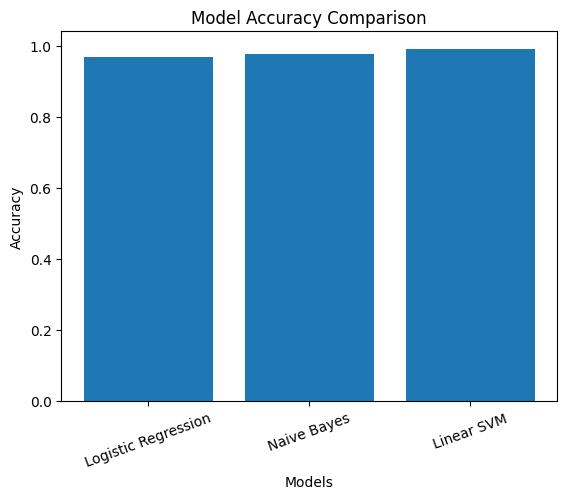

In [7]:
model_names = list(results.keys())
accuracies = [results[m]["accuracy"] for m in model_names]
f1_scores = [results[m]["f1"] for m in model_names]

plt.figure()
plt.bar(model_names, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

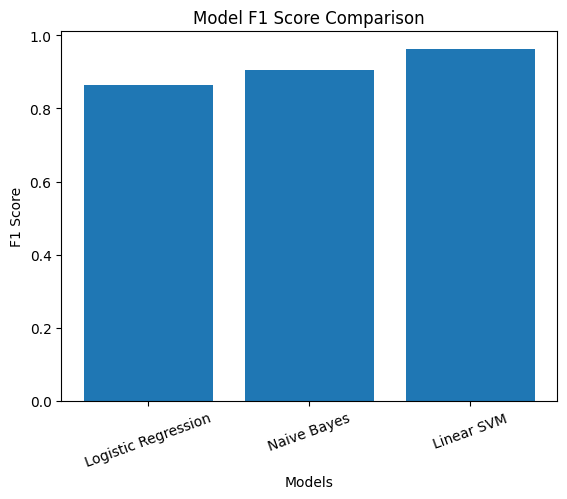

In [8]:
plt.figure()
plt.bar(model_names, f1_scores)
plt.title("Model F1 Score Comparison")
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.xticks(rotation=20)
plt.show()

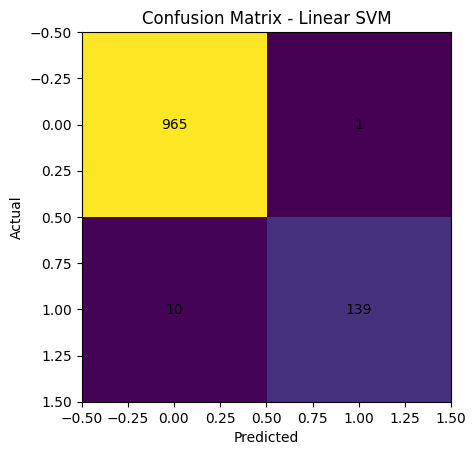

Best Model: Linear SVM


In [9]:
best_model_name = max(results, key=lambda x: results[x]['f1'])
best_model = models[best_model_name]
y_best_pred = best_model.predict(X_test_vec)

cm = confusion_matrix(y_test, y_best_pred)

plt.figure()
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()
print("Best Model:", best_model_name)

In [10]:
def predict_spam(email_text):
    email_vec = vectorizer.transform([email_text])
    prediction = best_model.predict(email_vec)[0]
    return "🚨 Spam Email" if prediction == 1 else "✅ Not Spam (Ham)"

# Test Example
sample_email = "Congratulations! You have won a free lottery ticket"
print("Prediction:", predict_spam(sample_email))

Prediction: ✅ Not Spam (Ham)


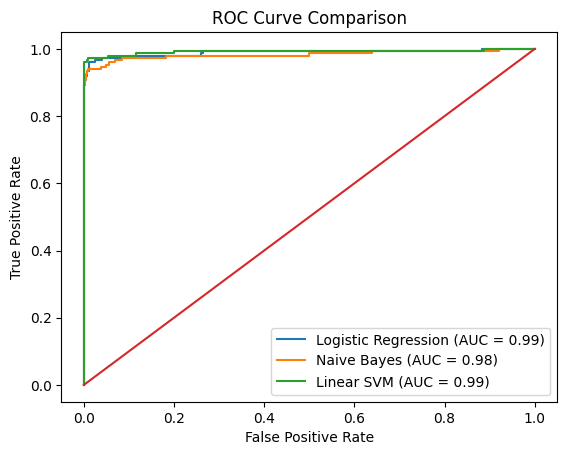

In [11]:
from sklearn.metrics import roc_curve, auc

plt.figure()

for name, model in models.items():
    # For SVM use decision_function, others use predict_proba
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_vec)[:, 1]
    else:
        probs = model.decision_function(X_test_vec)

    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1])  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

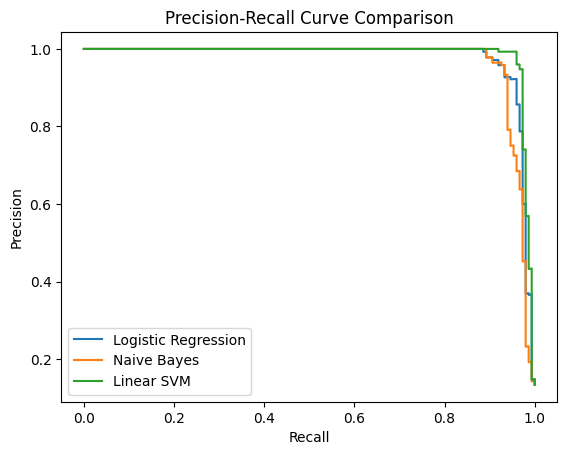

In [12]:
from sklearn.metrics import precision_recall_curve

plt.figure()

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_vec)[:, 1]
    else:
        probs = model.decision_function(X_test_vec)

    precision, recall, _ = precision_recall_curve(y_test, probs)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

In [13]:
emails = [
    "Congratulations! You have won a $1000 Walmart gift card. Click here to claim now.",
    "Urgent: Your bank account has been compromised. Verify your details immediately.",
    "You are selected for a free vacation to Dubai. Limited time offer!",
    "Get cheap medicines without prescription. Order now and save 50%.",
    "Winner!! Claim your free iPhone 15 now by clicking this link.",
]
for e in emails:
    print(e, " --> ", predict_spam(e))

Congratulations! You have won a $1000 Walmart gift card. Click here to claim now.  -->  🚨 Spam Email
Urgent: Your bank account has been compromised. Verify your details immediately.  -->  🚨 Spam Email
You are selected for a free vacation to Dubai. Limited time offer!  -->  ✅ Not Spam (Ham)
Get cheap medicines without prescription. Order now and save 50%.  -->  🚨 Spam Email
Winner!! Claim your free iPhone 15 now by clicking this link.  -->  🚨 Spam Email


In [14]:
emails = [
    "Dear user, your OTP for login is 839201. Do not share it with anyone.",
    "Limited period sale! Buy one get one free on all products.",
    "Your electricity bill for February is generated. Please pay before due date.",
    "Click here to reset your password immediately to avoid account suspension.",
    "Happy Birthday Satya! Wishing you a great year ahead."
]
for e in emails:
    print(e, " --> ", predict_spam(e))

Dear user, your OTP for login is 839201. Do not share it with anyone.  -->  ✅ Not Spam (Ham)
Limited period sale! Buy one get one free on all products.  -->  ✅ Not Spam (Ham)
Your electricity bill for February is generated. Please pay before due date.  -->  ✅ Not Spam (Ham)
Click here to reset your password immediately to avoid account suspension.  -->  ✅ Not Spam (Ham)
Happy Birthday Satya! Wishing you a great year ahead.  -->  ✅ Not Spam (Ham)
